# EXEMPLO PREENCHIDO — Projeto integrador da U01 à U14

**ID do projeto:** `PI-EXEMPLO-IMPRENSA`

Este notebook mostra, em sequência, como um mesmo projeto poderia evoluir
ao longo de todas as unidades da disciplina. Ele funciona como referência
de **encadeamento**, nível de detalhe, registro de decisões e continuidade
entre as entregas.

> **Atenção:** o projeto, os periódicos, os dados e todos os resultados são
> fictícios. Este material não representa uma pesquisa histórica real e não
> deve ser copiado como resposta. Cada estudante deve trabalhar com sua
> própria pergunta, seu corpus e suas evidências.

## Como ler este exemplo

1. Observe o que cada unidade recebe da etapa anterior.
2. Note que o corpus e a pergunta podem ser refinados, desde que a mudança
   seja registrada.
3. Compare decisões de adoção e de não adoção de métodos.
4. Use o caderno específico da unidade para produzir sua própria entrega.

## O que caracteriza a entrega em notebook

A entrega não é apenas um relatório textual nem uma coleção de códigos.
Ela deve construir uma sequência legível de evidências:

| Elemento | Função |
|---|---|
| texto antes do código | apresenta a pergunta e explica por que a operação será feita |
| código executável | realiza uma transformação, cálculo, tabela ou gráfico necessário |
| saída selecionada | torna o resultado inspecionável pelo leitor |
| análise depois da saída | interpreta padrões sem apenas repetir números ou formas |
| limites | registra o que a evidência não permite concluir |

Neste exemplo, a U03 constrói e verifica a base; a U04 explora tabelas e
distribuições; a U05 compara cenários; e a U11 examina uma série temporal.
As demais unidades mostram decisões que não exigem inserir código apenas
para aparentar tecnicidade.

| Percurso | Função no projeto fictício |
|---|---|
| U01–U05 | construir pergunta, corpus, base e comparação inicial |
| U06–U12 | avaliar métodos e incorporar somente os pertinentes |
| U13–U14 | auditar as conclusões e consolidar o projeto final |

## U01 — Proposta inicial


**ID:** `PI-EXEMPLO-IMPRENSA` — versão `v0.1-proposta`.

**Problema:** compreender como um corpus didático de periódicos operários
fictícios representa a relação entre educação e trabalho entre 1890 e 1910.

**Pergunta delimitada:** como a centralidade atribuída à educação e sua associação
discursiva com trabalho variam entre 1890–1899 e 1900–1910?

**Unidade:** artigo. **Corpus pretendido:** cerca de 300 artigos de quatro
periódicos fictícios, com imagem, transcrição, data, periódico e gênero.

**Operacionalização inicial:** “centralidade da educação” será observada por
anotação humana (`central`, `secundária`, `ausente`) e por frequência relativa de
vocabulário educacional. As duas medidas não são equivalentes.

**Limite:** o corpus é de conveniência e não representa toda a imprensa ou todas
as organizações do período.

**Passagem:** a U02 deverá verificar acesso, cobertura, direitos, qualidade das
imagens e viabilidade da anotação.

## U02 — Protocolo da base


**Versão herdada:** `v0.1-proposta`; pergunta mantida, corpus pretendido revisado.

**Fontes:** 268 imagens sintéticas atribuídas aos periódicos A–D. Após o piloto,
definiu-se incluir artigos com data e periódico identificáveis e excluir anúncios,
páginas repetidas e imagens sem legibilidade mínima.

**Corpus previsto:** 252 artigos; 16 imagens ficam no registro de exclusões.
A cobertura é maior depois de 1900 e o periódico D só aparece no segundo período.

**Identificador:** `PER-A-1894-003`; nunca será derivado apenas do título.
**Campos:** ID, periódico, data, gênero, página, caminho da imagem, transcrição,
precisão da data, motivo de exclusão e proveniência.

**Governança:** corpus inteiramente fictício e compartilhável; o protocolo seria
diferente com pessoas vivas ou acervo restrito.

**Decisão:** prosseguir, mas tratar desequilíbrio temporal e institucional como
limite, não como ausência neutra.

## U03 — Primeira base processável


**Entrada:** 252 registros previstos na U02, imagens e metadados preservados em
`dados/brutos/`.

**Transformações:** datas foram normalizadas sem apagar o valor recebido;
gêneros receberam vocabulário controlado; transcrições mantiveram vínculo com a
imagem; 12 artigos foram marcados como não processáveis segundo regra já prevista.

**Base processável:** `corpus-v1`, com 240 artigos, uma linha por artigo. As 12
exclusões permanecem em `registro_exclusoes.csv`.

**Testes:** 240 IDs únicos; nenhuma junção multiplicou artigos; todos os caminhos
de transcrição apontam para um arquivo; 18 datas possuem apenas precisão anual.

**Parecer:** a base permite exploração por período, periódico, gênero e texto,
mas comparações devem considerar a cobertura desigual e erros de OCR ainda não
corrigidos em parte das transcrições.

### Demonstração técnica — construir a base processável

A célula seguinte cria uma versão sintética e reproduzível do corpus.
Em uma pesquisa real, esta etapa leria os arquivos preservados em
`dados/brutos/`; aqui os dados são gerados apenas para que o exemplo
possa ser executado sem downloads.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

def criar_periodo(periodo, anos, composicao, media_frequencia):
    partes = []
    for periodico, quantidade, centrais in composicao:
        parte = pd.DataFrame({
            "periodo": periodo,
            "ano": rng.choice(anos, quantidade, replace=True),
            "periodico": periodico,
            "educacao_central": [True] * centrais
            + [False] * (quantidade - centrais),
            "genero": rng.choice(
                ["editorial", "notícia", "ensaio"],
                quantidade,
                p=[0.25, 0.45, 0.30],
            ),
            "tokens": np.maximum(
                120, rng.normal(720, 230, quantidade).round()
            ).astype(int),
        })
        partes.append(parte)
    periodo_df = pd.concat(partes, ignore_index=True)
    frequencias = rng.normal(media_frequencia, 2.2, len(periodo_df))
    frequencias += media_frequencia - frequencias.mean()
    periodo_df["freq_educacao_mil"] = frequencias.round(2)
    return periodo_df

df = pd.concat([
    criar_periodo(
        "1890–1899", range(1890, 1900),
        [("A", 40, 10), ("B", 40, 9), ("C", 30, 7)], 8.2,
    ),
    criar_periodo(
        "1900–1910", range(1900, 1911),
        [("A", 35, 13), ("B", 35, 12), ("C", 35, 12), ("D", 25, 12)],
        12.7,
    ),
], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

df.insert(0, "id_artigo", [f"ART-{i:03d}" for i in range(1, len(df) + 1)])
df["mencoes_educacao"] = (
    df["freq_educacao_mil"] * df["tokens"] / 1000
).round().clip(lower=0).astype(int)

display(df.head())

,id_artigo,periodo,ano,periodico,educacao_central,genero,tokens,freq_educacao_mil,mencoes_educacao
0,ART-001,1890–1899,1897,A,False,ensaio,636,11.19,7
1,ART-002,1890–1899,1890,A,True,notícia,884,11.41,10
2,ART-003,1890–1899,1896,C,False,editorial,799,8.79,7
3,ART-004,1890–1899,1897,C,False,ensaio,801,3.54,3
4,ART-005,1890–1899,1898,C,False,ensaio,773,9.83,8


In [2]:
# Verificações mínimas antes da análise
verificacoes = pd.Series({
    "linhas": len(df),
    "IDs únicos": df["id_artigo"].nunique(),
    "IDs ausentes": int(df["id_artigo"].isna().sum()),
    "anos mínimo e máximo": f"{df['ano'].min()}–{df['ano'].max()}",
    "frequências ausentes": int(df["freq_educacao_mil"].isna().sum()),
}, name="resultado")
display(verificacoes.to_frame())

,resultado
linhas,240
IDs únicos,240
IDs ausentes,0
anos mínimo e máximo,1890–1910
frequências ausentes,0


**Leitura da verificação.** Há 240 linhas e 240 identificadores únicos,
portanto cada linha pode representar um artigo sem duplicação de ID.
A cobertura vai de 1890 a 1910 e a variável usada na exploração não tem
valores ausentes. Esses testes não provam que a base é historicamente
representativa; apenas confirmam algumas condições técnicas necessárias.

## U04 — Relatório exploratório


**Base herdada:** `corpus-v1`, 240 artigos.

**Pergunta exploratória:** que padrões temporais e textuais justificam uma
comparação mais controlada entre os dois períodos?

**Resultado quantitativo fictício:** 24% dos 110 artigos de 1890–1899 e 38% dos
130 artigos de 1900–1910 foram anotados como educação central. O denominador é o
número de artigos de cada período.

**Resultado textual fictício:** a frequência do vocabulário educacional passou de
8,2 para 12,7 ocorrências por mil tokens. Concordâncias mostraram que “instrução”
aparece tanto em defesa da educação quanto em críticas institucionais.

**Retorno aos casos:** um artigo longo elevava a contagem bruta; a frequência
relativa reduziu, mas não eliminou, sua influência.

**Hipótese:** no corpus, a educação parece tornar-se mais central no segundo
período, mas a mudança pode decorrer da composição dos periódicos disponíveis.

### Exploração — resumir antes de interpretar

Primeiro calculamos os denominadores e as medidas por período. Depois
produzimos dois gráficos complementares: uma proporção baseada na
anotação humana e a distribuição de uma frequência lexical.

In [3]:
resumo = (
    df.groupby("periodo", observed=True)
    .agg(
        artigos=("id_artigo", "size"),
        artigos_centrais=("educacao_central", "sum"),
        proporcao_central=("educacao_central", "mean"),
        media_freq_mil=("freq_educacao_mil", "mean"),
        mediana_tokens=("tokens", "median"),
    )
)
display(resumo.round(3))

,artigos,artigos_centrais,proporcao_central,media_freq_mil,mediana_tokens
periodo,,,,,
1890–1899,110,26,0.236,8.2,691.0
1900–1910,130,49,0.377,12.7,731.5


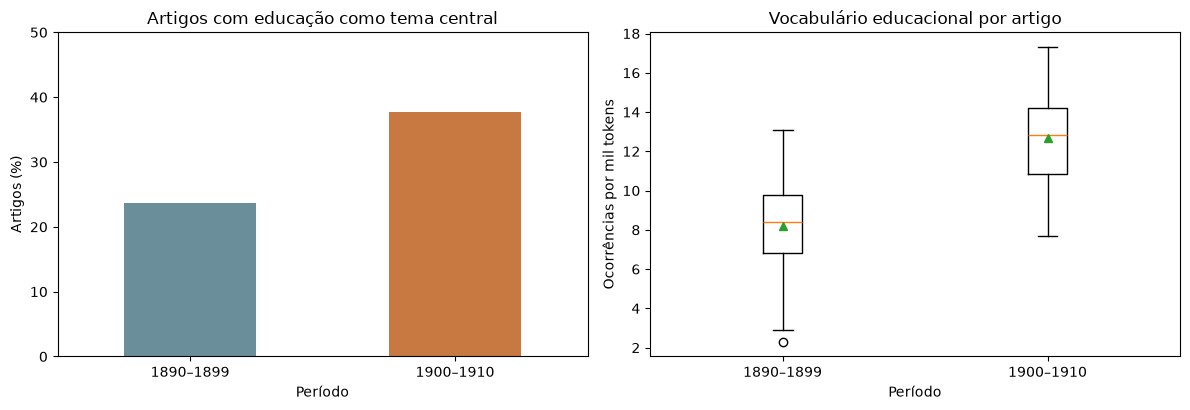

In [4]:
ordem = ["1890–1899", "1900–1910"]
fig, eixos = plt.subplots(1, 2, figsize=(12, 4.2))

(resumo.loc[ordem, "proporcao_central"] * 100).plot.bar(
    ax=eixos[0], color=["#6b8e9b", "#c87941"]
)
eixos[0].set_title("Artigos com educação como tema central")
eixos[0].set_xlabel("Período")
eixos[0].set_ylabel("Artigos (%)")
eixos[0].tick_params(axis="x", rotation=0)
eixos[0].set_ylim(0, 50)

dados_boxplot = [
    df.loc[df["periodo"].eq(periodo), "freq_educacao_mil"]
    for periodo in ordem
]
eixos[1].boxplot(dados_boxplot, tick_labels=ordem, showmeans=True)
eixos[1].set_title("Vocabulário educacional por artigo")
eixos[1].set_xlabel("Período")
eixos[1].set_ylabel("Ocorrências por mil tokens")

plt.tight_layout()
plt.show()

**Análise dos resultados.** O primeiro gráfico mostra aproximadamente
24% de artigos centrais no primeiro período e 38% no segundo. A altura
das barras só é comparável porque cada valor usa como denominador o total
de artigos do próprio período. O boxplot aponta também uma frequência
lexical maior depois de 1900, mas exibe a dispersão e impede que a média
seja confundida com o comportamento de todos os documentos.

As duas evidências convergem, mas medem coisas diferentes: uma categoria
atribuída ao artigo inteiro e ocorrências de vocabulário. Nenhum gráfico,
isoladamente, demonstra uma transformação geral da imprensa operária.

## U05 — Análise comparativa


**Contraste herdado:** 1890–1899 (`n=110`) versus 1900–1910 (`n=130`).

**Medida principal fictícia:** diferença de 14 pontos percentuais na proporção de
artigos anotados como educação central (`0,38 - 0,24`).

**Sensibilidade:** ao comparar apenas periódicos presentes nos dois períodos, a
diferença cai para 11 pontos percentuais. A direção permanece, mas a magnitude
depende da composição institucional.

**Casos:** um artigo típico de cada período, um texto extremo em extensão e um
artigo do segundo período que critica a escolarização qualificaram a leitura.

**Conclusão limitada:** há diferença descritiva neste corpus; ela não demonstra
mudança de toda a imprensa operária nem efeito causal do período.

**Diagnóstico:** classificação e análise temporal parecem aplicáveis; regressão
explicativa e análise espacial não parecem justificadas nesta versão.

### Comparação e análise de sensibilidade

Como o periódico D só existe no segundo período, repetimos a comparação
usando apenas A, B e C. Essa mudança testa quanto o resultado depende da
composição do corpus.

In [5]:
corpus_comum = df[df["periodico"].isin(["A", "B", "C"])]

cenarios = pd.DataFrame({
    "corpus completo": df.groupby("periodo")["educacao_central"].mean(),
    "somente periódicos A–C": corpus_comum.groupby("periodo")["educacao_central"].mean(),
}) * 100
cenarios.loc["diferença (p.p.)"] = (
    cenarios.loc["1900–1910"] - cenarios.loc["1890–1899"]
)
display(cenarios.round(1))

,corpus completo,somente periódicos A–C
periodo,,
1890–1899,23.6,23.6
1900–1910,37.7,35.2
diferença (p.p.),14.1,11.6


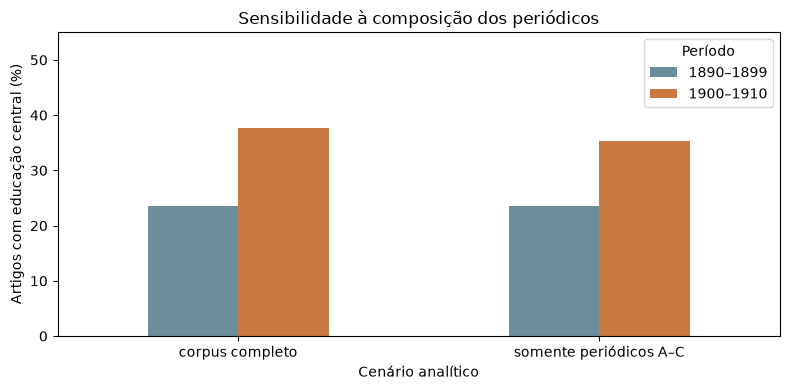

In [6]:
comparacao = cenarios.drop(index="diferença (p.p.)").T
comparacao.plot.bar(figsize=(8, 4), color=["#6b8e9b", "#c87941"])
plt.title("Sensibilidade à composição dos periódicos")
plt.xlabel("Cenário analítico")
plt.ylabel("Artigos com educação central (%)")
plt.xticks(rotation=0)
plt.legend(title="Período")
plt.ylim(0, 55)
plt.tight_layout()
plt.show()

**Análise dos resultados.** A diferença é de cerca de 14 pontos
percentuais no corpus completo e 12 pontos quando comparamos somente
periódicos presentes nos dois períodos. A direção do contraste permanece,
mas sua magnitude diminui. Portanto, a composição institucional explica
parte — não toda — da diferença observada. O resultado continua sendo
descritivo e restrito ao corpus.

## U06 — Associação ou rede


**Decisão:** Forma A, método complementar — rede de coocorrência entre
instituições e conceitos, alimentada posteriormente pela extração da U10.

**Regra:** duas entidades recebem uma aresta quando aparecem no mesmo artigo; o
peso é o número de artigos compartilhados, não a intensidade de uma relação social.

**Resultado fictício:** associações educacionais e sindicatos aparecem próximos
de “curso” e “biblioteca”, mas a inspeção mostrou que parte das coocorrências vem
de listas de eventos.

**Limite:** centralidade na rede textual não equivale a importância histórica.
A dependência da U10 foi registrada como inversão da ordem operacional.

## U07 — Regressão


**Decisão:** Forma B — não incorporar regressão ao projeto.

**Diagnóstico:** seria possível modelar a anotação “educação central”, mas o
corpus é de conveniência, possui forte desequilíbrio entre periódicos e só 240
casos. Um modelo multivariado criaria aparência de explicação sem desenho capaz
de sustentar causalidade.

**Laboratório:** a regressão foi executada nos dados didáticos da oficina para
aprender coeficientes, categorias de referência e resíduos.

**Alternativa:** manter a comparação estratificada por periódicos e realizar
análise de sensibilidade. O resultado do laboratório não integra a evidência do
projeto `PI-EXEMPLO-IMPRENSA`.

## U08 — Classificação


**Decisão:** Forma A — classificação como método principal.

**Categoria-alvo:** educação `central` versus `não central`, definida em guia de
anotação. Dois anotadores revisaram 40 casos; divergências foram discutidas antes
da anotação final de 120 artigos.

**Experimento fictício:** baseline majoritária com F1 macro 0,41; regressão
logística com TF-IDF, F1 macro 0,68 no teste preservado.

**Erros:** referências indiretas a ensino foram frequentemente omitidas; textos
com listas de escolas produziram falsos positivos.

**Decisão de uso:** o protótipo pode priorizar revisão humana, mas não substituir
a anotação nem produzir automaticamente categorias históricas definitivas.

## U09 — Agrupamento ou tópicos


**Decisão:** Forma B após piloto — não incorporar agrupamento ou tópicos.

**Piloto fictício:** soluções com quatro e cinco tópicos mudaram muito entre
sementes; dois tópicos refletiam tamanho e ruído de OCR, não temas interpretáveis.

**Risco:** nomear os grupos como correntes políticas daria substância histórica a
uma separação instável produzida pela representação.

**Aprendizagem:** o laboratório mostrou a necessidade de avaliar estabilidade e
ler documentos típicos e limítrofes.

**Alternativa:** manter a categoria anotada na U08 e usar concordâncias para
investigar vocabulário sem afirmar descoberta automática de temas.

## U10 — Extração de informações


**Decisão:** Forma A — extrair associações, sindicatos, escolas e localidades
mencionadas para apoiar a rede da U06.

**Esquema:** entidade, forma textual, tipo, ID do artigo, trecho, posição e ID
normalizado. A extração preserva cada menção, não apenas contagens agregadas.

**Avaliação fictícia em 60 artigos:** precisão 0,88 e revocação 0,76. Nomes
abreviados de associações foram a principal fonte de omissão; escolas com nomes
semelhantes exigiram desambiguação humana.

**Produto:** `entidades-v1.csv`, ligado por `id_artigo` e acompanhado de uma fila
de casos ambíguos. A base derivada não substitui os textos.

## U11 — Tempo ou espaço


**Decisão:** Forma A para o percurso temporal; Forma B para o espacial.

**Temporal:** proporção anual de artigos anotados como educação central, mostrada
apenas em anos com cobertura mínima declarada. Anos com poucos artigos aparecem
como pontos, sem linha contínua que sugira cobertura inexistente.

**Resultado fictício:** o aumento não é monotônico e se concentra em três anos;
isso enfraquece uma narrativa simples de crescimento contínuo.

**Espacial não adotado:** o local do periódico registra impressão, não o lugar do
evento ou o alcance da circulação. Um mapa confundiria unidades diferentes.

### Exploração temporal — cobertura e tendência no mesmo gráfico

Uma linha temporal pode sugerir continuidade mesmo quando alguns anos
têm poucos documentos. Por isso o código calcula também o número de
artigos por ano e só liga com uma linha os anos que atingem o limiar
didático de oito artigos.

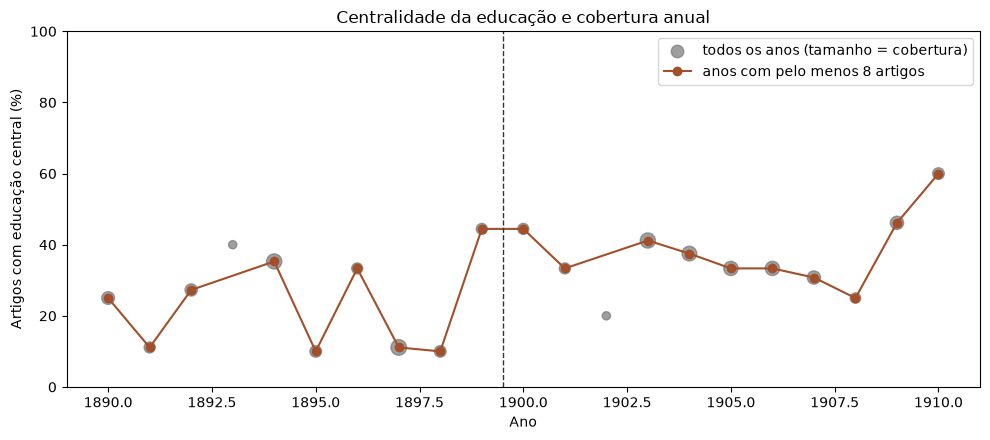

,ano,artigos,proporcao_central,percentual_central
0,1890,12,0.250000,25.000000
1,1891,9,0.111111,11.111111
2,1892,11,0.272727,27.272727
3,1893,5,0.400000,40.000000
4,1894,17,0.352941,35.294118
5,1895,10,0.100000,10.000000
6,1896,9,0.333333,33.333333
7,1897,18,0.111111,11.111111
8,1898,10,0.100000,10.000000
9,1899,9,0.444444,44.444444


In [7]:
anual = (
    df.groupby("ano")
    .agg(
        artigos=("id_artigo", "size"),
        proporcao_central=("educacao_central", "mean"),
    )
    .reset_index()
)
anual["percentual_central"] = anual["proporcao_central"] * 100

fig, eixo = plt.subplots(figsize=(10, 4.5))
eixo.scatter(
    anual["ano"], anual["percentual_central"],
    s=anual["artigos"] * 7, color="#777777", alpha=0.7,
    label="todos os anos (tamanho = cobertura)",
)
cobertura_suficiente = anual[anual["artigos"] >= 8]
eixo.plot(
    cobertura_suficiente["ano"],
    cobertura_suficiente["percentual_central"],
    color="#a34f2a", marker="o",
    label="anos com pelo menos 8 artigos",
)
eixo.axvline(1899.5, color="#333333", linestyle="--", linewidth=1)
eixo.set_title("Centralidade da educação e cobertura anual")
eixo.set_xlabel("Ano")
eixo.set_ylabel("Artigos com educação central (%)")
eixo.set_ylim(0, 100)
eixo.legend()
plt.tight_layout()
plt.show()

display(anual)

**Análise do gráfico.** Os percentuais oscilam bastante entre anos e o
tamanho dos pontos mostra que a cobertura também varia. O segundo período
tende a ocupar níveis mais altos, mas não há crescimento contínuo ano a
ano. A linha tracejada apenas separa os períodos definidos na pesquisa;
ela não prova que 1900 seja uma ruptura histórica. Essa leitura é mais
cautelosa do que resumir o gráfico como “a educação aumentou”.

## U12 — Modelos de linguagem


**Decisão:** Forma B após experimento controlado.

**Tarefa:** extrair organizações nos mesmos 40 artigos usados para avaliar a regra
e o modelo da U10.

**Resultado fictício:** o modelo de linguagem obteve F1 0,78, contra 0,80 da
abordagem de referência revisada; variou entre execuções e inventou uma expansão
para duas siglas ambíguas.

**Decisão de não uso:** não houve ganho suficiente para compensar menor
rastreabilidade e custo. As instruções e saídas foram preservadas como experimento,
mas não alimentam a base final.

## U13 — Validade e robustez


**Afirmação auditada:** a educação é mais central no segundo período deste corpus.

**Construto:** frequência lexical e anotação humana capturam dimensões diferentes;
a conclusão final não as trata como equivalentes.

**Sensibilidade:** a diferença anotada passa de 14 para 11 pontos percentuais ao
restringir a comparação aos periódicos comuns. Com uma regra de anotação mais
estrita, cai para 8 pontos.

**Erros:** OCR afeta sobretudo artigos do primeiro período; o classificador erra
referências indiretas; a rede super-representa listas de eventos.

**Conclusão revisada:** o corpus oferece evidência de uma diferença interna e
sensível à composição, não de uma transformação geral da imprensa do período.

## U14 — Projeto final


**Versão:** `v1.0-final`; corpus congelado `corpus-v1.2`.

**Narrativa:** a pergunta da U01 foi preservada, mas o corpus caiu de 300 artigos
pretendidos para 240 processáveis. A U04 formulou a hipótese temporal, a U05
mostrou sensibilidade à composição, a U08 ofereceu classificação assistida e a
U10 sustentou a rede da U06. Regressão, tópicos, mapa e modelo de linguagem foram
recusados com justificativa.

**Resultado central:** diferença descritiva na centralidade da educação entre os
períodos, qualificada por cobertura, periódicos e regras de anotação.

**Pacote:** README, corpus compartilhável fictício, dicionário, notebooks,
ambiente, tabelas, figuras, testes, manifesto e registro de mudanças.

**Próximo passo:** ampliar cobertura do primeiro período e revisar OCR antes de
qualquer argumento histórico mais amplo.

## Síntese das decisões metodológicas do exemplo

| Unidade | Decisão | Papel no argumento final |
|---|---|---|
| U06 | incorporar rede como complemento | explorar coocorrências, sem tratá-las como relações sociais comprovadas |
| U07 | não incorporar regressão | evitar aparência de explicação incompatível com o desenho |
| U08 | incorporar classificação assistida | priorizar revisão humana, sem automatizar categorias definitivas |
| U09 | não incorporar tópicos | evitar interpretar agrupamentos instáveis como correntes históricas |
| U10 | incorporar extração de entidades | sustentar a rede e preservar ligação com os trechos |
| U11 | incorporar tempo e recusar mapa | usar a dimensão bem medida e explicitar a inadequação da outra |
| U12 | não incorporar modelo de linguagem | ganho insuficiente diante da instabilidade e da menor rastreabilidade |

O resultado final não é a soma indiscriminada de todas as técnicas. É um
argumento no qual cada método foi escolhido, limitado ou recusado em função
da pergunta e da qualidade das evidências disponíveis.